In [2]:
import numpy as np
import matplotlib.pyplot as plt

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import graph_color as gc
from koala import plotting as pl
from koala.lattice import cut_boundaries
from koala.lattice import INVALID

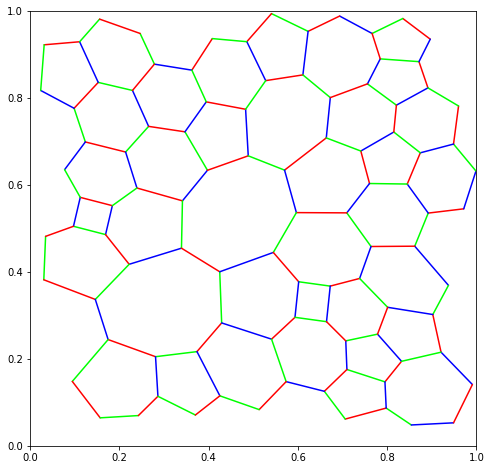

In [97]:
points = uniform(50)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice)
lattice = cut_boundaries(lattice)
lattice = gu.remove_trailing_edges(lattice)

colours = gc.color_lattice(lattice)

fig, ax = plt.subplots(figsize=(8, 8))
pl.plot_edges(lattice,ax=ax, labels=colours, color_scheme=['#ff0000', '#00ff00', '#0000ff'])
plt.savefig('colourings.pdf')


In [98]:
def intersection(lst1, lst2):
    return list(set(lst1) & set(lst2))

faces = np.zeros(lattice.n_plaquettes, dtype = int)
faces_set = np.zeros(lattice.n_plaquettes, dtype = int)
faces_set[0] = 1

while sum(faces_set) != len(faces_set):

    for n in range(lattice.n_edges):
        neighbours = lattice.edges.adjacent_plaquettes[n]
        
        edge_color_index = colours[n] + 1

        # if one is set and the other is not:
        if INVALID in neighbours:
            continue
        number_of_set_neigbours = sum(faces_set[neighbours])
        if number_of_set_neigbours == 1:
            # set the other one
            unset_one = neighbours[np.where(faces_set[neighbours] == 0)]
            set_one = neighbours[np.where(faces_set[neighbours] == 1)]

            faces_set[unset_one] = 1
            faces[unset_one] = faces[set_one]^edge_color_index

    


In [99]:
faces

array([0, 1, 1, 2, 3, 2, 0, 1, 3, 2, 1, 0, 0, 1, 2, 3, 1, 0, 2, 1, 3, 2,
       0, 0, 1, 2, 1, 2, 3, 2, 3, 1, 1, 2, 3, 2, 0])

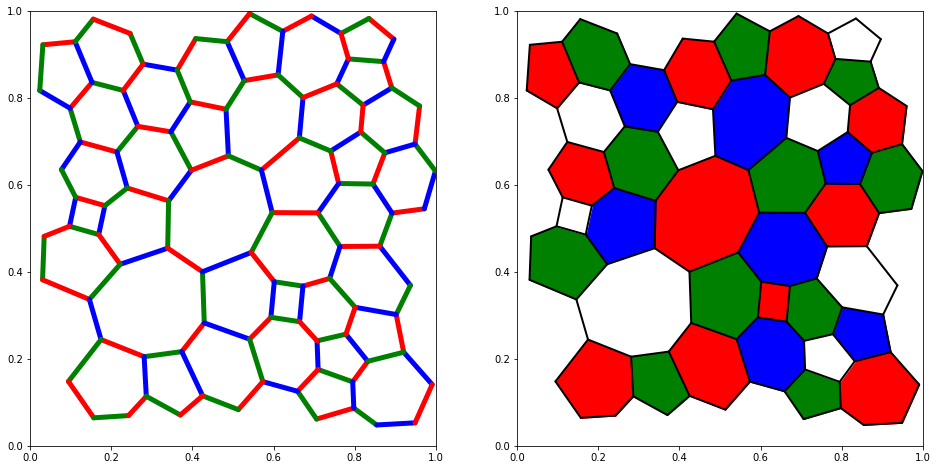

In [100]:
fig, ax = plt.subplots(1,2,figsize=(16, 8))
pl.plot_edges(lattice,ax=ax[0], labels=colours, color_scheme=['r','g','b'], linewidth=5)
pl.plot_edges(lattice,ax=ax[1], linewidth=2)
pl.plot_plaquettes(lattice,ax=ax[1], labels=faces, color_scheme=['w','r','g','b'])
plt.savefig('colourings.pdf')

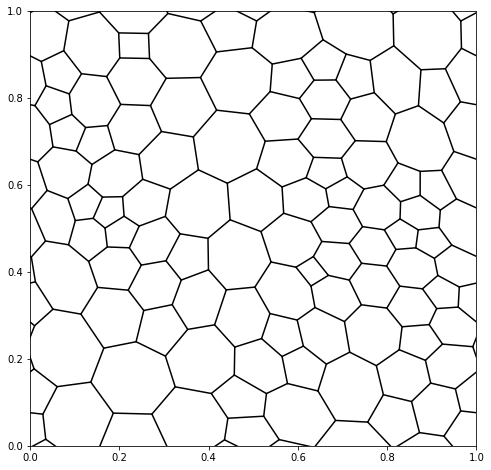

In [3]:
points = uniform(100)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice)

fig, ax = plt.subplots(figsize=(8, 8))
pl.plot_edges(lattice,ax=ax)
plt.savefig('lattice.pdf')